# Part 2.4 Sentiment Analysis

0    * Small family business - YMMV.
1    * Small family business - YMMV.
2    * Small family business - YMMV.
3    * Small family business - YMMV.
4    * Small family business - YMMV.
Name: comments, dtype: object
sentiment
Negative    1162
Positive      81
Neutral       16
Name: count, dtype: int64


/var/folders/p6/dvcp9zk51c534gxpxqw62v680000gp/T/ipykernel_41654/3636788465.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


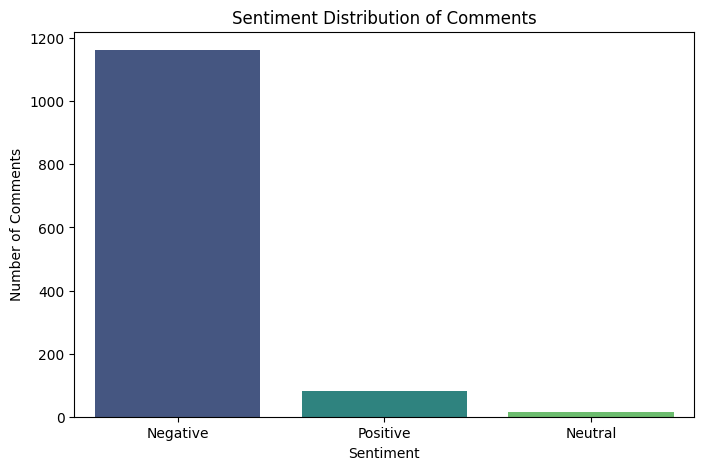

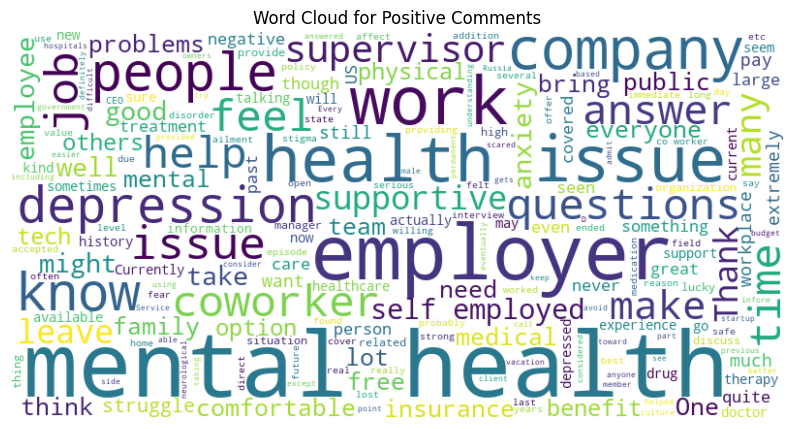

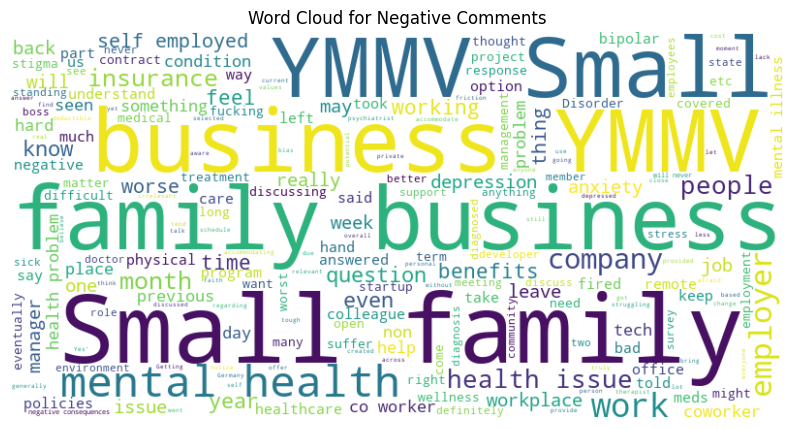

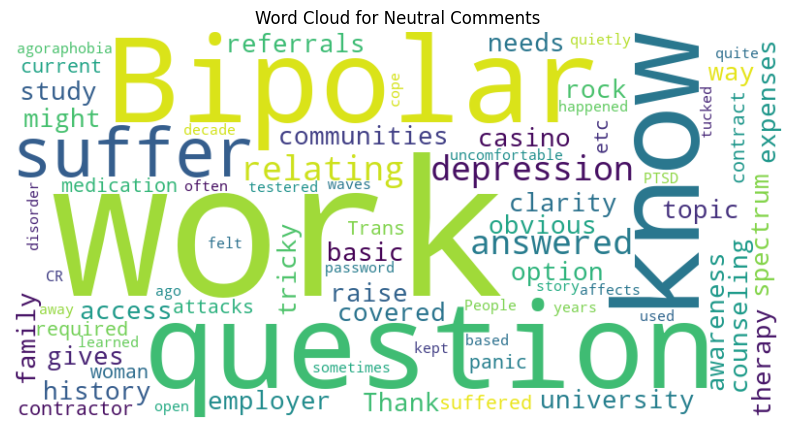

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# Load the dataset
file_path = '/Users/luischan/Downloads/preprocessed_survey.csv'
df = pd.read_csv(file_path)

# Check the first few rows of the 'comments' column
print(df['comments'].head())

# Drop rows where comments are missing
df_comments = df.dropna(subset=['comments'])

# Perform sentiment analysis on comments
def get_sentiment(comment):
    polarity = TextBlob(comment).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df_comments['sentiment'] = df_comments['comments'].apply(get_sentiment)

# Display sentiment distribution
sentiment_counts = df_comments['sentiment'].value_counts()
print(sentiment_counts)

# Plot sentiment distribution as a bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Sentiment Distribution of Comments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')

import os
if not os.path.exists("static"):
    os.makedirs("static")

# Save the current plot
plt.savefig("static/plot_{len(os.listdir(save_dir)) + 1}.png", bbox_inches='tight')
plt.close()

plt.show()

# Generate a word cloud for positive, negative, and neutral comments
def generate_wordcloud(sentiment):
    text = ' '.join(df_comments[df_comments['sentiment'] == sentiment]['comments'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {sentiment} Comments')
    plt.axis('off')
    
import os
if not os.path.exists("static"):
    os.makedirs("static")

# Save the current plot
plt.savefig("static/plot_{len(os.listdir(save_dir)) + 1}.png", bbox_inches='tight')
plt.close()

plt.show()

# Generate word clouds for each sentiment
for sentiment in ['Positive', 'Negative', 'Neutral']:
    generate_wordcloud(sentiment)

# Sentiment Analysis of Workplace Mental Health Comments

---

## **1. Steps in the Code**

1. **Data Preparation**:
   - Loaded the preprocessed dataset containing the `comments` column.
   - Dropped rows with missing comments.

2. **Sentiment Analysis**:
   - Used `TextBlob` to compute the **sentiment polarity** of each comment.
   - Categorized comments as **Positive**, **Negative**, or **Neutral** based on polarity:
     - **Polarity > 0**: Positive  
     - **Polarity < 0**: Negative  
     - **Polarity = 0**: Neutral  

3. **Visualization**:
   - Created a **bar chart** to show the distribution of sentiment categories.
   - Generated **word clouds** for positive, negative, and neutral comments to visualize frequently used words.

---

## **2. Results**

### **Sentiment Distribution**

| Sentiment | Number of Comments |
|-----------|--------------------|
| **Negative** | 1162              |
| **Positive** | 81                |
| **Neutral**  | 16                |


---

## **3. What It Means**

- **High Volume of Negative Comments**:  
  The majority of comments (1162 out of 1259) express negative sentiment. This reflects significant dissatisfaction and concerns related to mental health in the workplace.

- **Key Themes**:
  - **Negative**: Issues related to **small businesses**, **insurance coverage**, and **mental health** support.
  - **Positive**: Mentions of **supportive supervisors**, **mental health benefits**, and **insurance**.
  - **Neutral**: General queries or statements related to **work**, **bipolar disorder**, and **depression**.

- **Insights**:  
  - There is a clear need for better workplace support regarding mental health.
  - Small businesses may face challenges in providing adequate mental health resources.

The sentiment analysis highlights critical areas of concern and potential opportunities for employers to improve mental health support in the workplace.
